# OLS-Modelltraining

author: "Zhanna Davtyan"

In diesem Notebook ist die Fokus auf eine hypothesengeleitete Modellierung mit Ordinary Least Squares (OLS), um den Einfluss spezifischer Merkmale zu untersuchen.

***Hinweis:*** führen Sie dieses Notebook aus, nachdem Sie das `03 Explorative Datenanalyse` Notebook ausgeführt haben, um die erforderlichen Metadaten zu generieren.


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm 
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import preprocessing as pp
from statsmodels.api import qqplot


## Hypothese (Gesamtsignifikanz des Modells):

- H0: 
    - Die Gesamtheit der ausgewählten Prädiktoren (is_verified, account_category, follower_count etc.) hat keinen linearen Einfluss auf likes_log.
- H1: 
    - Mindestens einer der ausgewählten Prädiktoren hat einen signifikanten linearen Einfluss auf likes_log. 

In [48]:
df_gefiltert = pd.read_pickle('ergebnisse/verarbeitete_daten.pkl')

### Metadaten-Features für das OLS-Modell

OLS-Modell Metadaten Auswahl basiert auf der vorherigen explorativen Datenanalyse (EDA)

In [49]:
# FEATURES basierend auf die Ergebnisse der Explorativen Datenanalyse (EDA) 
feature_columns_for_ols = [
    
    # numerische Features
    
    'follower_count',       # Stark signifikant (+)
    'comment_count',        # Grenzwertig signifikant (+)
    'hashtag_count',        # Stark signifikant (-)
    # 'caption_length',     # Nicht signifikant 
    # 'mention_count',      # Nicht signifikant 
    # 'media_count_in_post',# Nicht signifikant 
    # 'hour_of_day',        # Nicht signifikant 
    # 'day_of_week',        # Nicht signifikant
    # 'month'               # Nicht signifikant    
    
    # kategoriale Features
    
    'is_verified',          # Stark signifikant (+)
    'is_professional_account', # Stark signifikant (+)
    'account_category',     # Viele Kategorien signifikant (+/-)
    'is_business_account',  # Grenzwertig signifikant (-)
    # 'post_type',          # Nicht signifikant
]

existing_ols_col = [col for col in feature_columns_for_ols if col in df_gefiltert.columns]
X = df_gefiltert[existing_ols_col].copy()
y = df_gefiltert['likes_log'].copy()
print(f"Anzahl Zeilen vor NaN-Behandlung in X_ols: {len(X)}")

# Fehlende Werte in 'account_category' mit 'Unbekannt' füllen
if 'account_category' in X.columns:
    X['account_category'] = X['account_category'].fillna('Unbekannt')
else: 
    X['account_category'] = 'Unbekannt'

print(f"Anzahl Zeilen nach NaN-Behandlung in X_ols: {len(X)}")
print("\nAusgewählte und bereinigte Features für OLS-Modell (X_ols):")
X.info()

# Identifiziere numerische und kategoriale Spalten 
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()

categorical_cols = sorted(list(set(categorical_cols)))
numerical_cols = sorted(list(set(numerical_cols)))


print(f"\nFinale numerische Features für Preprocessing (OLS): {numerical_cols}")
print(f"Finale kategoriale Features für Preprocessing (OLS): {categorical_cols}")



Anzahl Zeilen vor NaN-Behandlung in X_ols: 1968
Anzahl Zeilen nach NaN-Behandlung in X_ols: 1968

Ausgewählte und bereinigte Features für OLS-Modell (X_ols):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1968 entries, 0 to 1967
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   follower_count           1968 non-null   int64 
 1   comment_count            1968 non-null   int64 
 2   hashtag_count            1968 non-null   int64 
 3   is_verified              1968 non-null   bool  
 4   is_professional_account  1968 non-null   bool  
 5   account_category         1968 non-null   object
 6   is_business_account      1968 non-null   bool  
dtypes: bool(3), int64(3), object(1)
memory usage: 67.4+ KB

Finale numerische Features für Preprocessing (OLS): ['comment_count', 'follower_count', 'hashtag_count']
Finale kategoriale Features für Preprocessing (OLS): ['account_category', 'is_business_accoun

### Features

- Entfernung des StandardScaler nach dem OneHotEncoder bei kategorialen Features
    - Bei linearen Modellen hilft die Skalierung, Koeffizienten vergleichbar zu machen

In [50]:
# Preprocessing Pipelines
numerical_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Kategoriale Features werden mit OneHotEncoder verarbeitet 
categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')),
])


preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, numerical_cols),
    ('categorical', categorical_pipeline, categorical_cols)
], remainder='drop')


# Aufteilung in Trainings- und Testsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

print(f"\nGröße Trainingsdaten X (OLS): {X_train.shape}")
print(f"Größe Testdaten X (OLS): {X_test.shape}")

if X_train.empty:
    raise ValueError("X_train_ols_split ist leer nach dem Splitten. Überprüfe die Daten und Feature-Auswahl.")


Größe Trainingsdaten X (OLS): (1180, 7)
Größe Testdaten X (OLS): (788, 7)


### Training eines auf der Hypothese basierenden Modells (Lineare Regression mit statsmodels) 

In [51]:
ols_model = None

try:
    X_train_processed_ols_np = preprocessor.fit_transform(X_train)
    X_test_processed_ols_np = preprocessor.transform(X_test)
    print(f"Preprocessing abgeschlossen. Shape von X_train_processed_ols_np: {X_train_processed_ols_np.shape}")

    # Feature-Namen nach dem Preprocessing holen
    transformed_feature_names_ols = []
    if numerical_cols: # Nur wenn es numerische Spalten gibt
        transformed_feature_names_ols.extend(numerical_cols)
    if categorical_cols: # Nur wenn es kategoriale Spalten gibt
        ohe_transformer = preprocessor.named_transformers_['categorical'].named_steps['onehot']
        if hasattr(ohe_transformer, 'get_feature_names_out'):
            transformed_feature_names_ols.extend(ohe_transformer.get_feature_names_out(categorical_cols))
        else: 
            print("WARNUNG: get_feature_names_out nicht verfügbar für OHE. Feature-Namen in Summary könnten unvollständig sein.")


    num_cols_after_transform = X_train_processed_ols_np.shape[1]
    if transformed_feature_names_ols and num_cols_after_transform == len(transformed_feature_names_ols):
        current_cols_for_df = transformed_feature_names_ols
    else:
        print(f"WARNUNG: Anzahl extrahierter Namen ({len(transformed_feature_names_ols)}) passt nicht zu Spalten ({num_cols_after_transform}). Verwende generische Namen.")
        current_cols_for_df = [f"feature_{i}" for i in range(num_cols_after_transform)]
        transformed_feature_names_ols = current_cols_for_df 

    X_train_processed_ols_df = pd.DataFrame(X_train_processed_ols_np, columns=current_cols_for_df, index=X_train.index)
    X_test_processed_ols_df = pd.DataFrame(X_test_processed_ols_np, columns=current_cols_for_df, index=X_test.index)

    # Konstante für den Intercept 
    X_train_sm = sm.add_constant(X_train_processed_ols_df.reset_index(drop=True), has_constant='add')
    X_test_sm = sm.add_constant(X_test_processed_ols_df.reset_index(drop=True), has_constant='add')

    print("\nStarte OLS-Modelltraining (fokussiert)...")
    ols_model_obj = sm.OLS(y_train.reset_index(drop=True), X_train_sm)
    ols_model = ols_model_obj.fit() 
    print("OLS-Modelltraining (fokussiert) abgeschlossen.")

except Exception as e:
    print(f"Fehler während des Preprocessings oder OLS-Modelltrainings (fokussiert): {e}")

Preprocessing abgeschlossen. Shape von X_train_processed_ols_np: (1180, 31)

Starte OLS-Modelltraining (fokussiert)...
OLS-Modelltraining (fokussiert) abgeschlossen.


### Evaluierung des hypothesenbasierten Modells (OLS-Regression) 

In [52]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              likes_log   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.658
Method:                 Least Squares   F-statistic:                     74.09
Date:                Sun, 01 Jun 2025   Prob (F-statistic):          1.24e-248
Time:                        11:18:46   Log-Likelihood:                -2483.2
No. Observations:                1180   AIC:                             5030.
Df Residuals:                    1148   BIC:                             5193.
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

### Interpretation der OLS-Ergebnisse:

1. Gesamtsignifikanz des Modells:

- F-Statistik: 74.09 
    - Dies ist ein sehr hoher Wert, der darauf hindeutet, dass das Modell als Ganzes statistisch signifikant ist. H0 wird eindeutig verworfen, da der p-Wert (1.24e-248) weit unter 0.05 liegt. Die 31 ausgewählten Prädiktoren (Df Model) leisten gemeinsam einen signifikanten Beitrag zur Erklärung der Varianz in likes_log.(siehe auch unten die F-Verteilung und t-Verteilung Diagramme).

2. Modellgüte:
- R-squared: 0.667: 
    - Ca. 66.7% der Varianz in der log-transformierten Like-Anzahl (likes_log) können durch die im Modell enthaltenen Features erklärt werden.

- Adj. R-squared: 0.658: 
    - Unter Berücksichtigung der 31 Prädiktoren werden ca. 65.8% der Varianz erklärt. Dieser Wert ist gut und nur geringfügig niedriger als der R², was für die gewählte Feature-Anzahl spricht.

3. Degrees of Freedom (Df):
- Df Model: 31: 
    - Das Modell enthält 31 Prädiktoren, die zur Erklärung der Varianz in likes_log beitragen.

- Df Residuals: 1180: 
    - Freiheitsgrade der Residuen. Das Verhältnis von Beobachtungen zu Prädiktoren (1180/31≈38) ist gut und deutet auf eine stabilere Schätzung hin.

#### Interpretation ausgewählter Features und Koeffizienten:

- Intercept/Konstante: coef: 3.5628, P>|t|: 0.000 
    - Der erwartete likes_log-Wert, wenn alle skalierten numerischen Features ihren Mittelwert (Null) hätten und alle kategorialen Features in ihrer jeweiligen Referenzkategorie wären.

##### Numerische Features (standardisiert):

- follower_count: coef: 0.4502, P>|t|: 0.000
    - (H0 verworfen). Eine Erhöhung der follower_count um eine Standardabweichung vom Mittelwert ist mit einem durchschnittlichen Anstieg von likes_log um ca. 0.4502 verbunden. Hochsignifikant.

- comment_count: coef: 0.1504, P>|t|: 0.015
    - Eine Erhöhung der comment_count um eine Standardabweichung ist mit einem durchschnittlichen Anstieg von likes_log um ca. 0.1504 verbunden. Signifikant.

- hashtag_count: coef: -0.7954, P>|t|: 0.000    
    - Eine Erhöhung der hashtag_count um eine Standardabweichung ist mit einem durchschnittlichen Rückgang von likes_log um ca. 0.7954 verbunden. Hochsignifikant und ein starker negativer Effekt.

##### Kategoriale Features (Dummy-Variablen, Koeffizienten im Vergleich zur Referenzkategorie):

- is_verified_True: coef: 2.1014, P>|t|: 0.000
    - Verifizierte Accounts haben im Durchschnitt einen um ca. 2.10 höheren likes_log-Wert als nicht-verifizierte Accounts (Referenzkategorie). Starker positiver Effekt.

- is_professional_account_True: coef: 4.0250, P>|t|: 0.000
    - Professionelle Accounts haben im Durchschnitt einen um ca. 4.03 höheren likes_log-Wert als nicht-professionelle Accounts (Referenzkategorie). Sehr starker positiver Prädiktor im Modell.

- is_business_account_True: coef: -0.3787, P>|t|: 0.024
    - Business Accounts haben im Durchschnitt einen um ca. 0.38 niedrigeren likes_log-Wert als Nicht-Business-Accounts (Referenzkategorie). Signifikanter negativer Effekt.

##### Kritische Nuance zur Interpretation der Koeffizientengrößen:
- Die Koeffizienten der standardisierten numerischen Variablen (z.B. follower_count: 0.4502) und der nicht-standardisierten Dummy-Variablen (z.B. account_category_Arts & entertainment: 1.6811) sind nicht direkt miteinander vergleichbar, um zu sagen, welches Feature "mehr Einfluss" hat.
Der Koeffizient 0.4502 für follower_count bezieht sich auf eine Änderung um eine Standardabweichung der Follower. Der Koeffizient 1.6811 für die Dummy-Variable bezieht sich auf den Unterschied zwischen dem Vorhandensein dieser Kategorie und der Referenzkategorie.
Es ist nicht korrekt zu schlussfolgern, dass "Arts & Entertainment" einen größeren Einfluss hat als "Follower Count", nur weil 1.6811 > 0.4502 ist. Sie messen unterschiedliche Dinge. Die p-Werte (P>|t|) sind hier der bessere Indikator für die statistische Signifikanz des jeweiligen Einflusses. 


##### Diagnostik der Modelannahmen:

- Residuenverteilung: Prob(Omnibus): 0.000, Skew: -0.687, Kurtosis: 6.652
    - Kritisch: Die Residuen sind nicht normalverteilt. Dies ist eine Verletzung einer Kernannahme der OLS-Regression und bedeutet, dass die Standardfehler, t-Werte, p-Werte und Konfidenzintervalle der Koeffizienten nicht vollständig zuverlässig sind für die statistische Inferenz. Die Koeffizientenschätzungen selbst können noch die besten linearen Schätzer sein, aber die Aussagekraft der Signifikanztests ist eingeschränkt.
- Autokorrelation: Durbin-Watson: 2.022. 
    - Dieser Wert liegt sehr nahe bei 2, was ideal ist und gegen eine signifikante Autokorrelation der Residuen spricht.
- Multikollinearität: Cond. No.: 42.8.
    - Kritisch: Ein Wert über 30 deutet auf moderate bis starke Multikollinearität hin. Das bedeutet, dass einige deiner Prädiktorvariablen wahrscheinlich stark miteinander korrelieren. Das heißt, die Schätzungen der einzelnen Regressionskoeffizienten können instabil werden (d.h., kleine Änderungen in den Daten können zu großen Änderungen in den Koeffizienten führen). Es wird schwierig, den isolierten Effekt eines einzelnen Prädiktors zu bestimmen, da sich die Effekte überlappen.

## Fazit:

Das OLS-Modell zeigt eine starke Gesamtsignifikanz und erklärt einen großen Teil der Varianz in likes_log. Die signifikanten Prädiktoren liefern wertvolle Einblicke in die Faktoren, die die Like-Anzahl beeinflussen.
Bestätigte Haupteinflüsse: follower_count, is_verified, is_professional_account und account_category bleiben sehr wichtige Prädiktoren. Der negative Einfluss von hashtag_count ist ebenfalls robust. Die nicht-normalverteilte Residuen sind aber problematisch. Dies ist eine schwerwiegende Verletzung der OLS-Annahmen und schränkt die Verlässlichkeit der statistischen Inferenz (p-Werte, Konfidenzintervalle) ein. Das Vorhandensein moderater bis starker Multikollinearität macht die Interpretation der einzelnen Koeffizientengrößen und -vorzeichen auch schwierig und potenziell irreführend. 

## Modelverbesserung:

Die Nicht-Normalverteilung der Residuen bleibt die größte Herausforderung für die statistische Inferenz (Gültigkeit der p-Werte und Konfidenzintervalle). Ein Random Forest ist der logische nächste Schritt, um die Limitationen des OLS-Modells zu überwinden, insbesondere die Nicht-Normalverteilung der Residuen und die inhärente Unfähigkeit, komplexe nicht-lineare Beziehungen und Interaktionen ohne manuelle Spezifikation zu modellieren. Die Erkenntnisse aus dem OLS sind dabei wertvoller Input für die Feature-Auswahl und das Verständnis des Random Forest Modells.



### Diagramme des OLS-Modells

#### F-Verteilungs-Diagramm

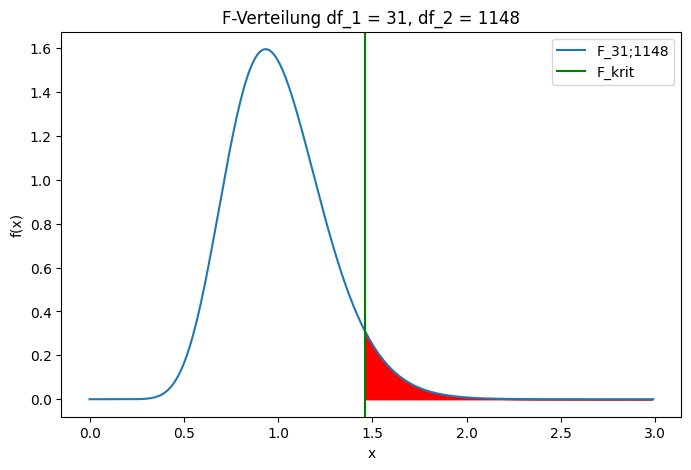

In [53]:
alpha = 0.05

# Freiheitsgrade
df_1 = ols_model.df_model  # Anzahl der Regressoren
df_2 = ols_model.df_resid  # Freiheitsgrade der Residuen

# Kritischer F-Wert für das Modell
F_krit = stats.f.ppf(1 - alpha, df_1, df_2)

b1, b2 = 0, 3
x_v = np.arange(b1, b2, 0.01)
plt.figure(figsize=(8, 5))
plt.plot(x_v, stats.f.pdf(x_v, df_1, df_2), label=f'F_{df_1:.0f};{df_2:.0f}')
fill_l = np.arange(F_krit, b2, (b2-F_krit)/100)
plt.fill_between(fill_l, stats.f.pdf(fill_l, df_1, df_2), color='red')
plt.axvline(F_krit, color='green', label='F_krit')
plt.legend()
plt.title(f'F-Verteilung df_1 = {df_1:.0f}, df_2 = {df_2:.0f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

##### Interpretation des F-Verteilungs-Diagramms

Der F-Wert des Modells beträgt 74.09 (aus dem OLS-Summary).
Dieser Wert liegt weit im roten Bereich (deutlich rechts vom kritischen Wert)
Daher wird H₀ mit sehr hoher Sicherheit abgelehnt. Die Wahrscheinlichkeit, einen so hohen F-Wert zufällig zu beobachten, wenn tatsächlich kein Zusammenhang besteht, ist extrem gering (p ≈ 1.24e-248).

#### t-Verteilungs-Diagramm

Ablehnungsbereich für H0: t < -1.962 oder t > 1.962


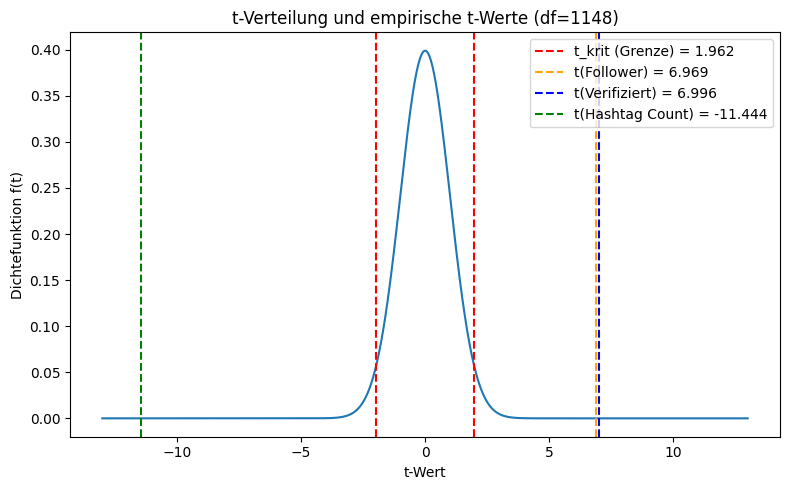

In [54]:
alpha = 0.05 # Signifikanzniveau
feature_name_follower = 'follower_count' 
feature_name_verified = 'is_verified_True' 
feature_name_professional = 'is_professional_account_True' 
feature_name_hashtag = 'hashtag_count' 

t_value_follower = ols_model.tvalues.get(feature_name_follower, np.nan) 
t_value_verified = ols_model.tvalues.get(feature_name_verified, np.nan)
t_value_third_hashtag = ols_model.tvalues.get(feature_name_hashtag, np.nan)



x_t = np.arange(-13, 13, 0.01) 
plt.figure(figsize=(8, 5))
plt.plot(x_t, stats.t.pdf(x_t, df=ols_model.df_resid))

# Kritische Werte für zweiseitigen Test
c_lower, c_upper = stats.t.interval(1 - alpha, df=ols_model.df_resid)
print(f'Ablehnungsbereich für H0: t < {c_lower:.3f} oder t > {c_upper:.3f}')

plt.axvline(c_lower, linestyle='--', color='red')
plt.axvline(c_upper, linestyle='--', color='red', label=f't_krit (Grenze) = {c_upper:.3f}')

# Empirische t-Werte
plt.axvline(t_value_follower - 0.1, linestyle='--', color='orange', label=f't(Follower) = {t_value_follower:.3f}')
plt.axvline(t_value_verified, linestyle='--', color='blue', label=f't(Verifiziert) = {t_value_verified:.3f}')
plt.axvline(t_value_third_hashtag, linestyle='--', color='green', label=f't(Hashtag Count) = {t_value_third_hashtag:.3f}')

plt.xlabel('t-Wert')
plt.ylabel('Dichtefunktion f(t)')
plt.title(f't-Verteilung und empirische t-Werte (df={ols_model.df_resid:.0f})')
plt.legend(loc=1)
plt.tight_layout()
plt.show()

##### Interpretation des t-Verteilungs-Diagramms
Das Diagramm zeigt eine t-Verteilung mit 1148 Freiheitsgraden und visualisiert die Hypothesentests für drei wichtige Prädiktoren aus Ihrem OLS-Modell.
Die kritischen t-Werte bei α = 0.05 definieren den Ablehnungsbereich für die Nullhypothese. Werte außerhalb dieses Bereichs sind statistisch signifikant. Alle drei t-Werte liegen deutlich außerhalb des Nicht-Ablehnungsbereichs. Sie befinden sich weit rechts vom kritischen Wert 1.962, was zeigt, dass diese Variablen einen hochsignifikant positiven Einfluss auf die logarithmierte Anzahl von Likes haben.

#### Tukey-Anscombe-Plot

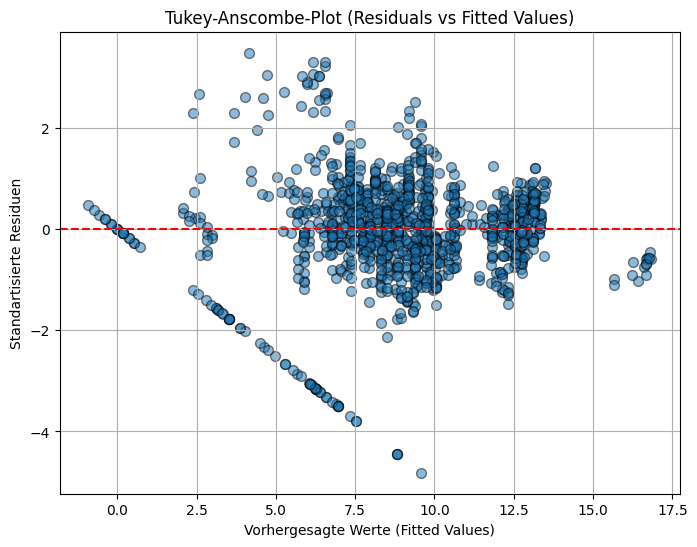

In [55]:
fitted_vals = ols_model.fittedvalues
standardized_residuals = ols_model.resid / ols_model.resid.std()

plt.figure(figsize=(8, 6))
plt.axhline(y=0, color='red', linestyle='--')
plt.scatter(fitted_vals, standardized_residuals, alpha=0.5, edgecolors='k', s=50)
plt.title('Tukey-Anscombe-Plot (Residuals vs Fitted Values)')
plt.xlabel('Vorhergesagte Werte (Fitted Values)')
plt.ylabel('Standartisierte Residuen')
plt.grid(True)
plt.show()



##### Interpretation des Tukey-Anscombe-Plots
Dieser Plot hilft, die Annahme der Homoskedastizität (konstante Varianz der Fehler/Residuen) und die Linearitätsannahme zu überprüfen. Idealerweise sollten die Punkte zufällig und gleichmäßig um die Nulllinie streuen, ohne erkennbares Muster.
Die mögliche Heteroskedastizität und die nicht perfekt zufällige Verteilung deuten darauf hin, dass das lineare Modell möglicherweise nicht alle systematischen Muster in den Daten erfasst. Die erkennbaren Muster könnten auf fehlende Prädiktoren oder nicht-lineare Zusammenhänge hindeuten. 

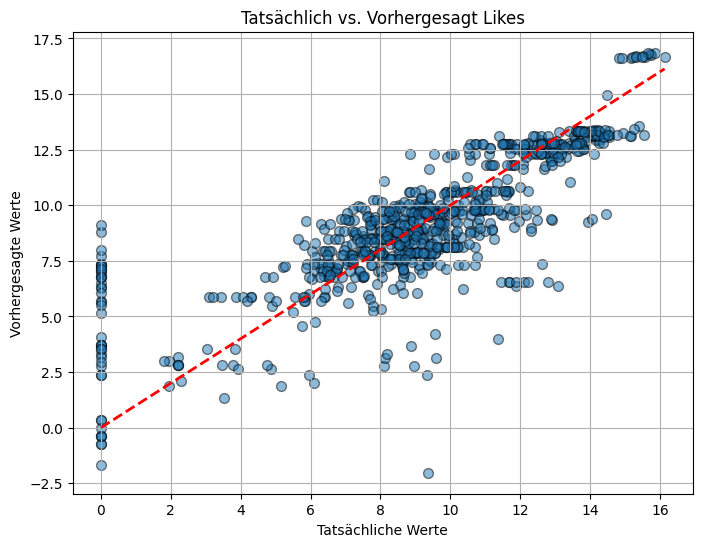

In [56]:
y_pred_test = ols_model.predict(X_test_sm)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5, edgecolors='k', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Tatsächliche Werte")
plt.ylabel("Vorhergesagte Werte")
plt.title(f"Tatsächlich vs. Vorhergesagt Likes")
plt.grid(True)
plt.show()

#### Q-Q-Plot

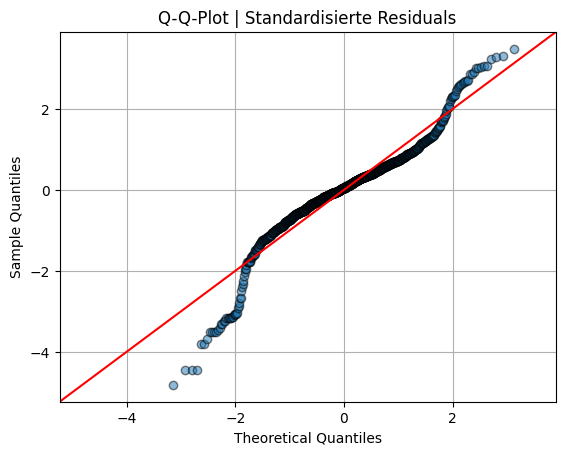

In [57]:
fig = qqplot(pp.scale(ols_model.resid), line='45', alpha=0.5)
ax = fig.gca()
for i in ax.get_children():
	if hasattr(i, 'set_markeredgecolor'):
		i.set_markeredgecolor('k')
	if hasattr(i, 'set_markersize'):
		i.set_markersize(6)
plt.title("Q-Q-Plot | Standardisierte Residuals")
plt.grid(True)
plt.show()

##### Interpretation des Q-Q-Plots
In der Mitte (zwischen -1 und +1 auf der x-Achse): Die Residuen folgen der Normalverteilungslinie relativ gut. Aber die S-Form deutet auf Abweichungen hin, die Normalverteilungannahmen verletzen.

#### Histogramm der Residuen

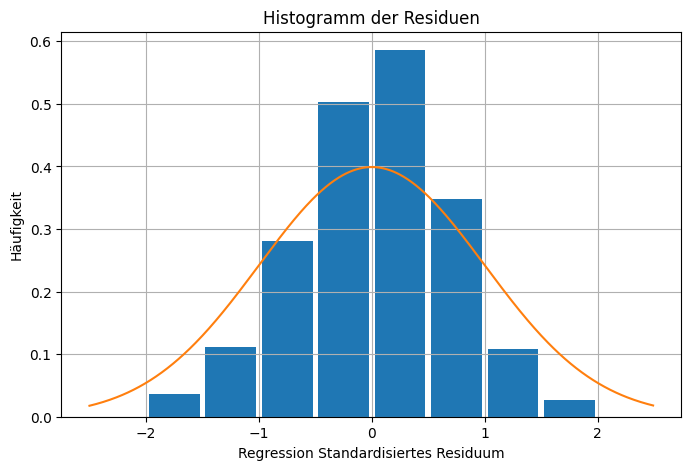

In [58]:
fig = plt.figure(figsize = (8,5))
bins = [i/2 for i in range(-4,5)]
# Daten werden zentriert und auf Einheitsvarianz skaliert
data = pp.scale(ols_model.resid)
plt.hist(data, bins = bins, rwidth = 0.9, density = True)
x = np.arange(-2.5, 2.5, 0.01)
plt.plot(x, stats.norm.pdf(x, loc = 0, scale = 1))
plt.title('Histogramm der Residuen')
plt.xlabel('Regression Standardisiertes Residuum')
plt.ylabel('Häufigkeit')
plt.grid(True)
plt.show()

##### Interpretation des Histogramms der Residuen

- Positive Aspekte:

Die Verteilung ist um Null zentriert.
Sie ist weitgehend symmetrisch, ohne starke Schiefe.

- Abweichungen von der Normalverteilung:

Die Verteilung ist spitzer (höhere Dichte um den Mittelpunkt).
Das Histogramm zeigt eine höhere Konzentration in der Mitte als die Normalverteilungskurve vorhersagt.
Die Randbereiche folgen nicht genau der erwarteten Normalverteilung.

### Für die Übertragung von Variablen in ein neues Notebook

In [60]:
# Modell in Pickle-Datei speichern
import pickle

# Option 1: Modell separat speichern
with open('ols_model.pkl', 'wb') as f:
    pickle.dump(ols_model, f)

# Option 2: Modell zusammen mit den anderen Daten speichern
data_to_save = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'X': X,
    'y': y,
    'numerical_cols': numerical_cols,
    'categorical_cols': categorical_cols,
    'ols_model': ols_model  # Modell hinzufügen
}

with open('ergebnisse/modelle/ols_complete_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)